In [ ]:
import numpy as np
import scipy.signal as si
import matplotlib.pyplot as plt

from scipy.constants import c

In [ ]:
from lisainstrument import Instrument

In [ ]:
from pytdi import LISATDICombination
from pytdi.intervar import ETA_SET

X0_ETA = LISATDICombination.from_string("131 -121")
X0 = X0_ETA @ ETA_SET

## Exercise 1: Laser frequency noise suppression for different generations of TDI

TDI combinations are classified according to their generation. Each generation suppresses laser noise to a different degree:

| Generation | Laser noise cancels for... | Variable |
|---|---|---|
| 0 | equal and constant arms | $X_0$ |
| 1 | unequal but constant arms | $X_1$ |
| 2 | flexing (time-varying) arms | $X_2$ |

Below, you find a depiction of the corresponding photon paths for the zeroth and first-generation Michelson variable.

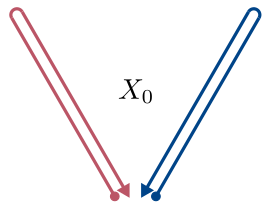 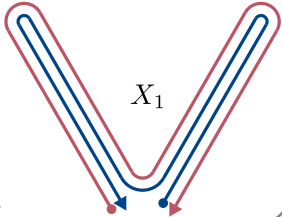

Now we use the Keplerian orbit file from the example notebook, such that the arms flex like they will in reality. The orbits decide the delays, and those decide which generation works.

1. Take the simulation code from the example notebook and only include laser frequency noise in the simulation (only mention `"laser"` in the list of noises to include). What can you observe in the estimated ASDs of the interferometric measurements? How do the models for OMS and test-mass acceleration noise compare with the data?
2. Compute the zeroth (defined above), first and second-gerneration Michelson variables (from `from pytdi.michelson import X1, X2`) and estimate their ASDs. How well does each generation suppress laser frequency noise for time-varying arms (the simulation assumes Keplerian orbits)?

In [ ]:
# Nominal noise parameterizations

nu0 = 281600000000000.0 # central laser frequency in Hz
lambda0 = c / nu0

def asd_oms(f, level=6.35e-12, f_knee=2e-3):
    """Amplitude spectral density of OMS noise

    Args:
        level: overall level in units of m/rtHz
        f_knee: frequency below the ASD increases
    """
    level_nu = level * (2 * np.pi * f) / lambda0 # convert from displacement units to frequency units
    return level_nu * np.sqrt((1 + (f_knee / f)**4))
    
def asd_tm(f, level=2.4e-15, f_knee=4e-4, f_break=8e-3):
    """Amplitude spectral density of test mass acceleration noise

    Args:
        level: overall level in units of m/s^2/rtHz
        f_knee: frequency below the ASD increases
        f_break: frequency above the ASD increases
    """
    level_nu = level / (2 * np.pi * f) / lambda0 # convert from acceleration units to frequency units
    return level_nu * np.sqrt((1 + (f_knee / f)**2) * (1 + (f / f_break)**4))

In [ ]:
fs = 4 # sampling rate of the data (Hz)
size = (3600 * 24) * fs # one day of simulation in number of samples

instru = Instrument(
    size=size,
    dt=1 / fs,
    orbits="orbits.h5", # path to orbit file
    orbit_dataset="tcb/ltt", # choose time frame of the measurements
    lock="six", # disable laser locking, each laser is stabilized on its own cavity
    oms_asds=(6.35e-12, 0, 0, 0, 0, 0), # OMS noise level in (sci_carrier, sci_usb, tmi_carrier, tmi_usb, ref_carrier, ref_usb) in m/rtHz
    testmass_asds=2.4e-15, # TM noise level in m/s^2/rtHz
)

# only include OMS and test-mass noise in the simulation
instru.disable_all_noises(excluding=["laser"])

# run simulation and store result
instru.export_hdf5("data/lisa.h5", overwrite=True)

In [ ]:
# options for spectral estimation
BUFFER = 1000 # number samples to discard at the beginning and the end of each TDI combination to remove boundary effects
welch_kwargs = dict(window=("kaiser", si.kaiser_beta(240)), nperseg=50_000, fs=fs, detrend=None)

In [ ]:
from pytdi import Data
from pytdi.michelson import X1, X2

In [ ]:
# Load simulated data
data = Data.from_instrument("data/lisa.h5")

In [ ]:
# inspect the data in the Fourier domain by estimating ASDs and comparing them to the noise models
freqs, psd_sci_12 = si.welch(data.measurements["sci_12"][BUFFER:-BUFFER], **welch_kwargs)
freqs, psd_tmi_12 = si.welch(data.measurements["tmi_12"][BUFFER:-BUFFER], **welch_kwargs)

plt.loglog(freqs, np.sqrt(psd_sci_12), label="SCI data")
plt.loglog(freqs[1:], asd_oms(freqs[1:]), label="SCI model")

plt.loglog(freqs, np.sqrt(psd_tmi_12), label="TMI data")
plt.loglog(freqs[1:], 2 * asd_tm(freqs[1:]), label="TMI model")

plt.xlabel("Frequency (Hz)")
plt.ylabel("ASD (Hz/rtHz)")
plt.legend()

In [ ]:
x0 = X0.build(**data.args)(data.measurements)
x1 = X1.build(**data.args)(data.measurements)
x2 = X2.build(**data.args)(data.measurements)

In [ ]:
# inspect the TDI combination in the Fourier domain by estimating its ASD and comparing it to the noise models
freqs, psd_x1 = si.welch(x1[BUFFER:-BUFFER], **welch_kwargs)
freqs, psd_x0 = si.welch(x0[BUFFER:-BUFFER], **welch_kwargs)
freqs, psd_x2 = si.welch(x2[BUFFER:-BUFFER], **welch_kwargs)

plt.loglog(freqs, np.sqrt(psd_x0), label=r"$X_0$ data")
plt.loglog(freqs, np.sqrt(psd_x1), label=r"$X_1$ data")
plt.loglog(freqs, np.sqrt(psd_x2), label=r"$X_2$ data")

plt.ylim(1e-12, 1e0)

plt.xlabel("Frequency (Hz)")
plt.ylabel("ASD (Hz/rtHz)")
plt.legend()

## Exercise 2: The quasi-orthogonal channels $A$, $E$ and $T$

The quasi-orthogonal TDI channels $A$, $E$ and $T$ are linear combinations of $X$, $Y$ and $Z$ that have uncorrelated noise. This property is quite delicate and relies on two strong assumptions: i) the triangular constellation has equal arms and ii) noises have identical levels. In practise both assumptions break: i) the LISA constellation is flexing throughout the year and arm length differ by a few percent, and ii) optical benches will not be exactly identlical leading to differences in noise levels. However, we can construct a simulation where both assumputions hold.

1. Simulate one day of LISA data at a sampling rate of 4 Hz including OMS in the ISC and test-mass noise in the TMI. For this experiment choose static and equal arms by setting `orbits={"12": 8.3, "23": 8.3, "31": 8.3, "13": 8.3, "32": 8.3, "21": 8.3}` (no orbit file required). Export the result to disk and read it using PyTDI's `Data` interface. This time, compute the full set of second-generation Michelson variables $X_2$, $Y_2$ and $Z_2$ (you need to import them the same way as done for $X_2$). In the next step, let's estimate not only the power spectral densities (PSDs) of $X_2$, $Y_2$ and $Z_2$ but also their cross spectral densities (CSDs) using scipy's function `si.csd` which works similar to `si.welch` but takes a pair measurements as inputs. The CSD is a measure of how correlated two measurements are; a vanishing CSD indicates uncorrelated noises. plot the PSD alongside the absolute value of the CSD (in general it's complex valued) to compare them.
2. Repeat the exercise with the quasi-orthogonal channels $A_2$, $E_2$ and $T_2$. Start by importing them from PyTDI `from pytdi.ortho import A2, E2, T2`, evaluate them numerically and recalculate PSDs and CSDs. Can you spot a difference between AET and XYZ? To make it more pronounced try decreasing `nperseg` to 2000.

In [ ]:
fs = 4 # sampling rate of the data (Hz)
size = (3600 * 24) * fs # one day of simulation in number of samples
oms_asds = (6.35e-12, 0, 0, 0, 0, 0)
orbits = {"12": 8.3, "23": 8.3, "31": 8.3, "13": 8.3, "32": 8.3, "21": 8.3}

instru = Instrument(
    size=size,
    dt=1 / fs,
    orbits=orbits,
    lock="six",
    oms_asds=oms_asds,
    testmass_asds=2.4e-15, # TM noise level in m / s^2 / rtHz
)

instru.disable_all_noises(excluding=["oms", "test-mass"])

instru.export_hdf5("data/lisa.h5", overwrite=True)

In [ ]:
from pytdi import Data
from pytdi.michelson import X2, Y2, Z2

In [ ]:
data = Data.from_instrument("data/lisa.h5")
x2 = X2.build(**data.args)(data.measurements)
y2 = Y2.build(**data.args)(data.measurements)
z2 = Z2.build(**data.args)(data.measurements)

In [ ]:
# options for spectral estimation
BUFFER = 1000
welch_kwargs = dict(window=("kaiser", si.kaiser_beta(240)), nperseg=10_000, fs=fs, detrend=None)

freqs, psd = si.welch(x2[BUFFER:-BUFFER], **welch_kwargs)
freqs, csd = si.csd(x2[BUFFER:-BUFFER], y2[BUFFER:-BUFFER], **welch_kwargs)

plt.loglog(freqs, psd, label=r"$X_2$ PSD")
plt.loglog(freqs, np.abs(csd), label=r"$X_2$, $Y_2$ CSD")

plt.ylim(1e-20, 1e-6)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD/CSD (Hz/rtHz)")
plt.legend()

In [ ]:
from pytdi.ortho import A2, E2, T2

a2 = A2.build(**data.args)(data.measurements)
e2 = E2.build(**data.args)(data.measurements)
t2 = T2.build(**data.args)(data.measurements)

In [ ]:
BUFFER = 1000
welch_kwargs = dict(window=("kaiser", si.kaiser_beta(240)), nperseg=2_000, fs=fs, detrend=None)

freqs, psd_a2 = si.welch(a2[BUFFER:-BUFFER], **welch_kwargs)
freqs, psd_e2 = si.welch(e2[BUFFER:-BUFFER], **welch_kwargs)
freqs, psd_t2 = si.welch(t2[BUFFER:-BUFFER], **welch_kwargs)
freqs, csd_a2_e2 = si.csd(a2[BUFFER:-BUFFER], e2[BUFFER:-BUFFER], **welch_kwargs)

plt.loglog(freqs, psd_a2, label=r"$A_2$ PSD")
plt.loglog(freqs, psd_e2, label=r"$E_2$ PSD")
# plt.loglog(freqs, psd_t2, label=r"$T_2$ PSD")
plt.loglog(freqs, np.abs(csd_a2_e2), label=r"$A_2$, $E_2$ CSD")

plt.ylim(1e-20, 1e-6)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD/CSD (Hz/rtHz)")
plt.legend()